# BQ8 — เครือขนาดใหญ่ได้เปรียบจริงหรือไม่

**คำถาม:** เครือขนาดใหญ่ได้เปรียบจริงหรือไม่ — **คุณภาพดีกว่า** หรือ**แค่กดต้นทุนแรงงาน**
— ผู้ใช้คือ CEO

คำถามนี้ตั้งมาดี เพราะมันบังคับให้แยกสองคำอธิบายออกจากกัน ไม่ใช่แค่ดูว่าเครือใหญ่ทำกำไรไหม
เครื่องมือที่ใช้แยกคือดู **ปัจจัยนำเข้าด้านแรงงาน** (ชั่วโมงพยาบาล, สัดส่วนพยาบาลวิชาชีพ,
อัตราลาออก) เทียบกับ **ผลลัพธ์ด้านคุณภาพ** (คะแนนดาว, ค่าปรับ) พร้อมกัน

- ถ้าเครือใหญ่คะแนนดีกว่า **และ** จัดพยาบาลเท่ากันหรือมากกว่า → ได้เปรียบจากการบริหารจริง
- ถ้าคะแนนเท่าหรือแย่กว่า **และ** จัดพยาบาลน้อยกว่า → กดต้นทุนแรงงาน

## 1. ข้อจำกัดที่ต้องเช็คก่อนเริ่ม — ข้อมูลเครือมีงวดไหน

คอลัมน์เครือถูกเพิ่มเข้า ProviderInfo ในปี 2568 ทุกแถวของงวดปี 2562 จึงชี้ไปที่
เครือ "Unknown" ถ้าไม่เช็คก่อน การเปรียบเทียบจะเงียบ ๆ กลายเป็นการเปรียบเทียบที่ว่างเปล่า

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import charts
import queries as q

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

con = q.connect()
print(q.available_periods(con).to_string(index=False))

 period_key     period  year  facilities
   20190101 2019-01-01  2019       15578
   20260401 2026-04-01  2026       14699
   20260601 2026-06-01  2026       14695
   20260701 2026-07-01  2026       14693


In [2]:
print(q.chain_data_periods(con).to_string(index=False))

    period  period_key  facilities  with_chain_data
2019-01-01    20190101       15578              0.0
2026-04-01    20260401       14699          14699.0
2026-06-01    20260601       14695          14695.0
2026-07-01    20260701       14693          14693.0


→ ใช้ได้เฉพาะงวดปี 2569 **BQ8 ตอบข้ามยุคไม่ได้** และนั่นเป็นข้อจำกัดของข้อมูลต้นทาง
ไม่ใช่ของการออกแบบ

## 2. ดึงข้อมูลเปรียบเทียบตามขนาดเครือ

In [3]:
frame, context = q.segment_compare(con, "chain_size_band")
frame[["segment", "facilities", "beds", "occupancy", "avg_rating",
       "nurse_hprd", "rn_hprd", "rn_share", "turnover_pct",
       "fines_per_bed", "share_fined"]].round(4)

,segment,facilities,beds,occupancy,avg_rating,nurse_hprd,rn_hprd,rn_share,turnover_pct,fines_per_bed,share_fined
0,Independent (1),4193,420255.0,0.7848,3.2449,4.0938,0.7282,0.1779,41.5500,270.3222,0.4121
1,Small chain (2-9),1997,206816.0,0.7991,2.9579,3.7878,0.6516,0.1720,44.5291,370.5724,0.4782
2,Medium chain (10-49),5201,572612.0,0.8156,2.8282,3.6379,0.5721,0.1573,45.9170,360.6391,0.4832
3,Large chain (50+),3276,367192.0,0.8010,2.9234,3.5271,0.5789,0.1641,46.1787,299.9586,0.4777


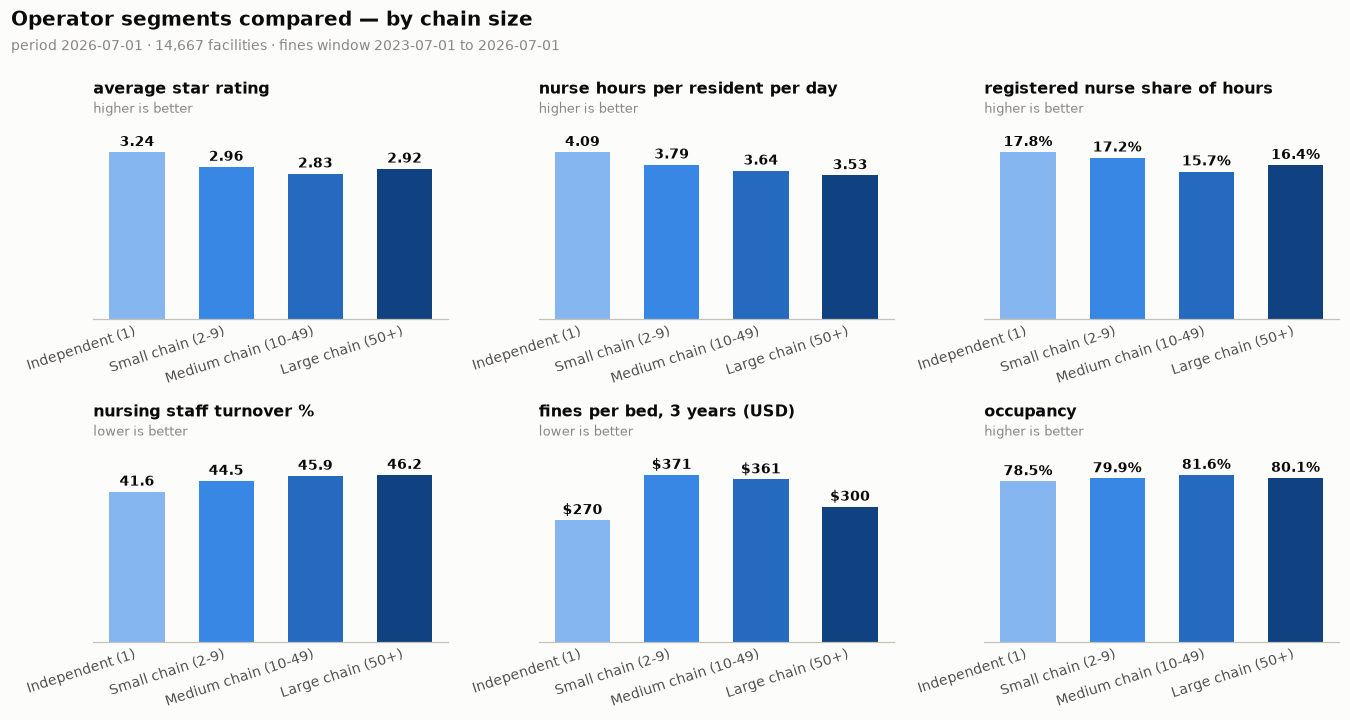

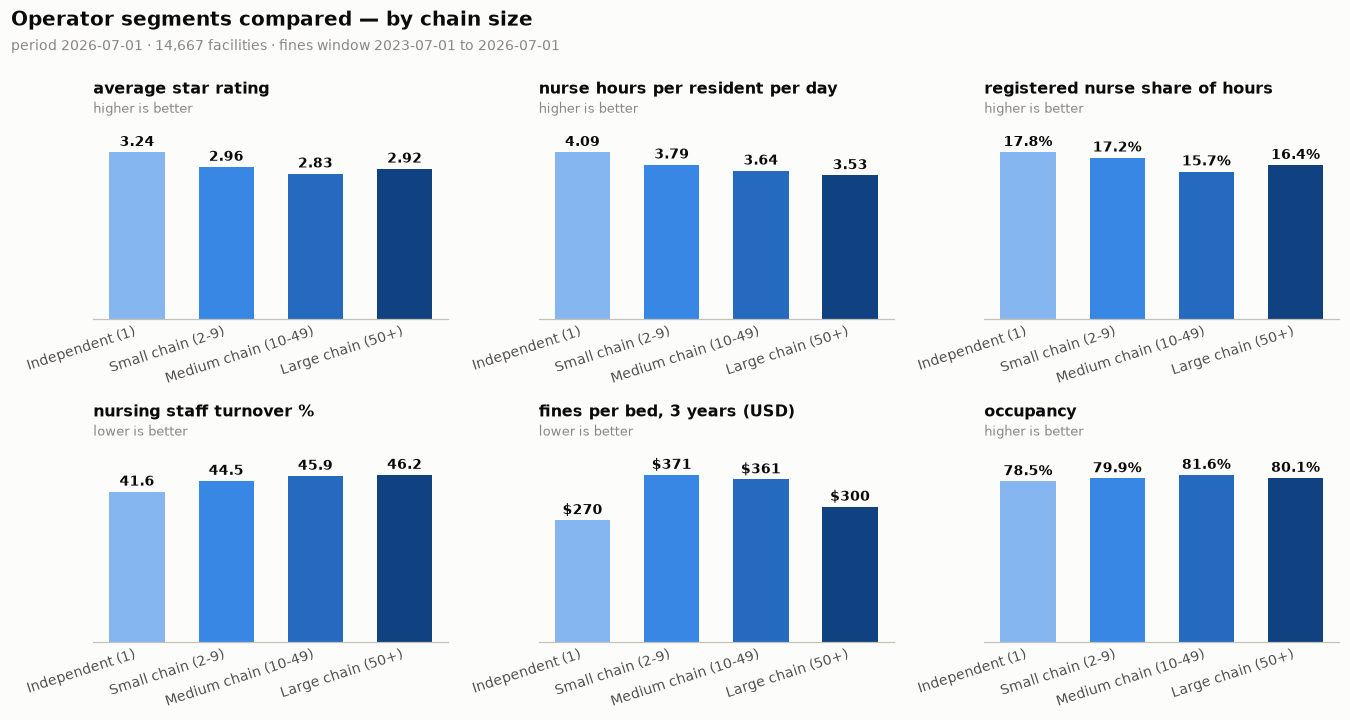

In [4]:
fig = charts.segment_small_multiples(frame, context, palette=charts.BAND_RAMP)
fig.savefig("bq8_segments.png", dpi=150, bbox_inches="tight")
fig

อ่านได้ทันทีสามอย่าง: ชั่วโมงพยาบาล**ลดลง**ตามขนาดเครือ · อัตราลาออก**เพิ่มขึ้น** ·
และคะแนนดาวของเครือทุกขนาด**ต่ำกว่า**บ้านอิสระ

แต่ยังสรุปไม่ได้ เพราะมีข้อโต้แย้งที่ชัดเจนรออยู่

## 3. ข้อโต้แย้งที่ต้องปิด — เครือส่วนใหญ่เป็น for-profit

ถ้าเครือเกือบทั้งหมดเป็น for-profit แล้ว BQ2 บอกว่า for-profit จัดพยาบาลน้อยกว่าอยู่แล้ว
ตารางในข้อ 2 ก็จะออกมาหน้าตาเดิม **แม้ขนาดเครือจะไม่มีผลอะไรเลย**

In [5]:
cross = q.segment_cross(con)
counts = cross.pivot_table(index="chain_size", columns="ownership",
                           values="facilities", aggfunc="sum", observed=True)
share = counts.div(counts.sum(axis=1), axis=0)
print("จำนวนสถานพยาบาล:")
print(counts.to_string())
print("\nสัดส่วนในแต่ละแถบขนาด:")
print(share.round(3).to_string())

จำนวนสถานพยาบาล:
ownership             For profit  Non profit  Government
chain_size                                              
Independent (1)             1931        1678         584
Small chain (2-9)           1455         443          99
Medium chain (10-49)        4570         540          91
Large chain (50+)           2889         214         173

สัดส่วนในแต่ละแถบขนาด:
ownership             For profit  Non profit  Government
chain_size                                              
Independent (1)            0.461       0.400       0.139
Small chain (2-9)          0.729       0.222       0.050
Medium chain (10-49)       0.879       0.104       0.017
Large chain (50+)          0.882       0.065       0.053


ยืนยันว่าสัมพันธ์กันจริง — เครือใหญ่เป็น for-profit เกือบทั้งหมด
ดังนั้นต้องดูขนาดเครือ **ภายในกลุ่มเจ้าของเดียวกัน** ทีละกลุ่ม

## 4. กราฟที่แยกสองคำอธิบายออกจากกัน

ถ้าแต่ละเส้นลาดลงด้วยตัวเอง แปลว่าขนาดเครือทำอะไรบางอย่างที่รูปแบบการถือครองอธิบายไม่ได้

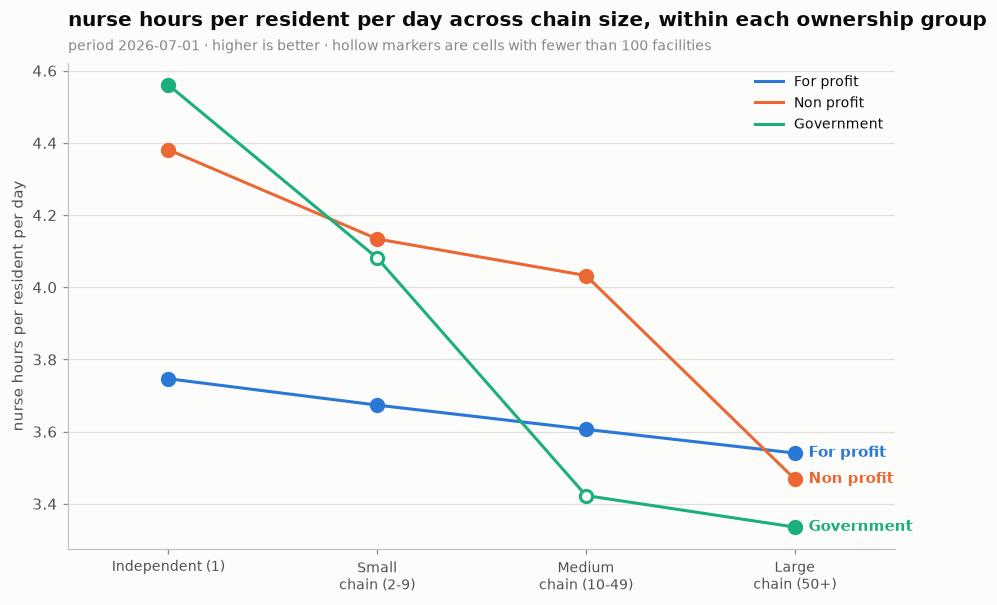

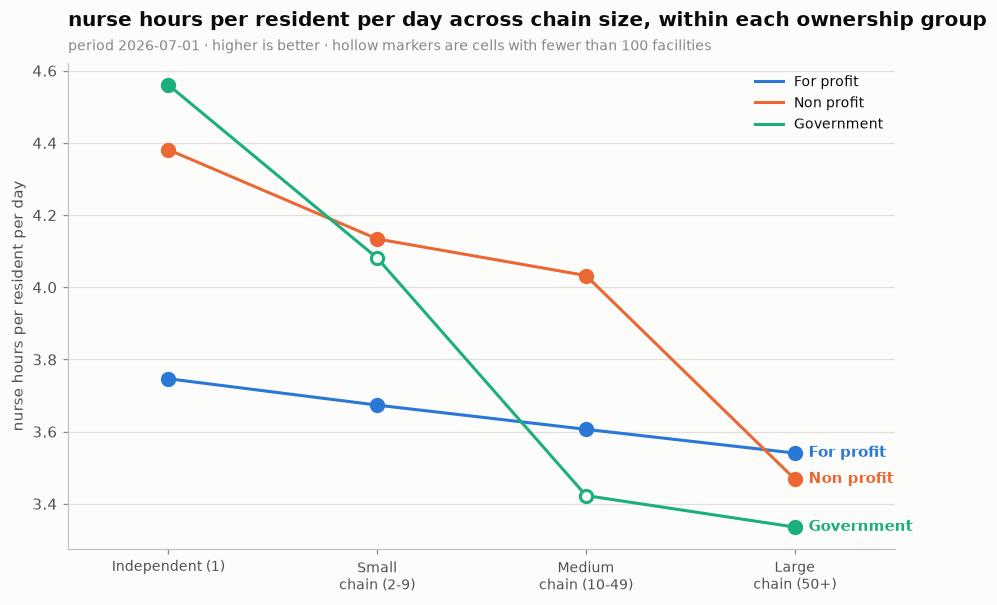

In [6]:
fig = charts.controlled_lines(cross, "nurse_hprd", context)
fig.savefig("bq8_controlled_nurse.png", dpi=150, bbox_inches="tight")
fig

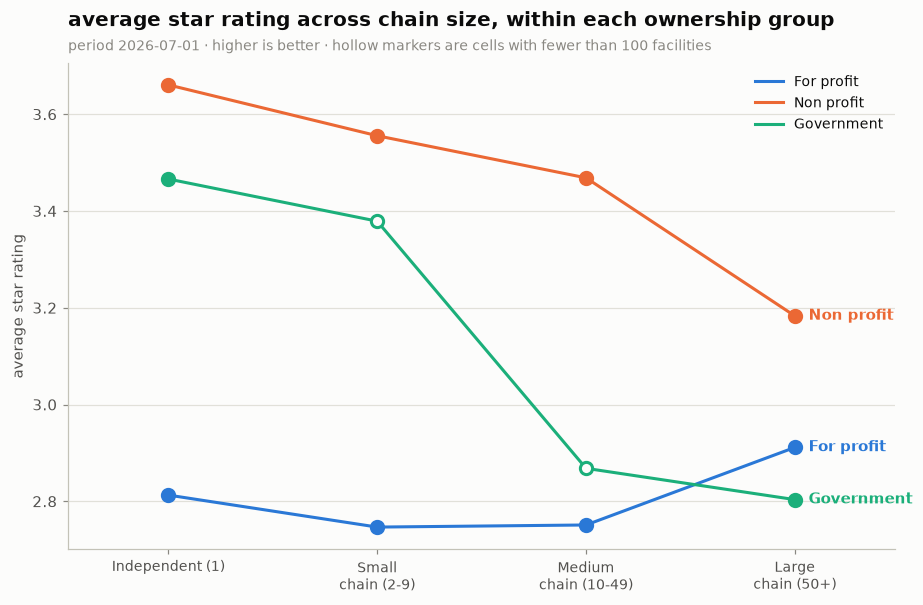

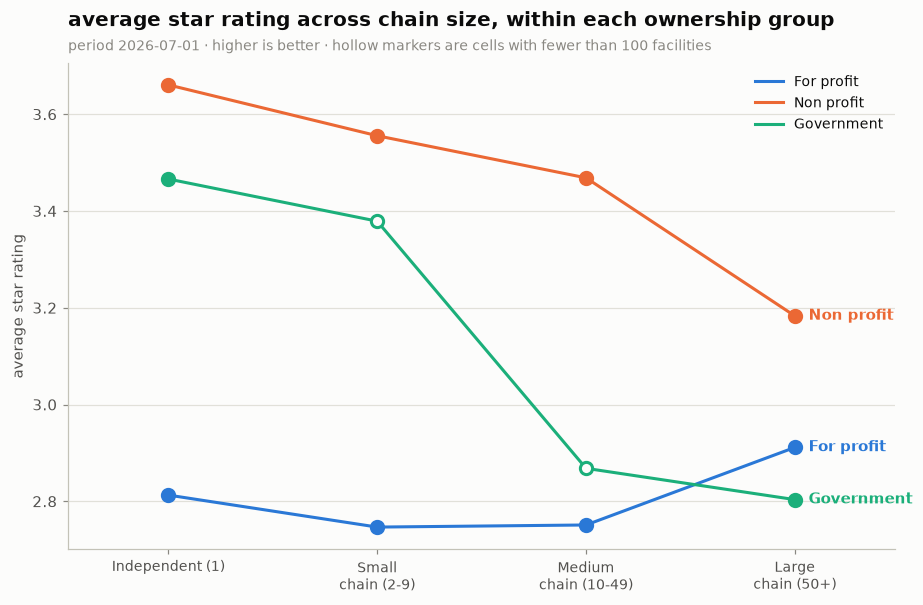

In [7]:
fig = charts.controlled_lines(cross, "avg_rating", context)
fig.savefig("bq8_controlled_rating.png", dpi=150, bbox_inches="tight")
fig

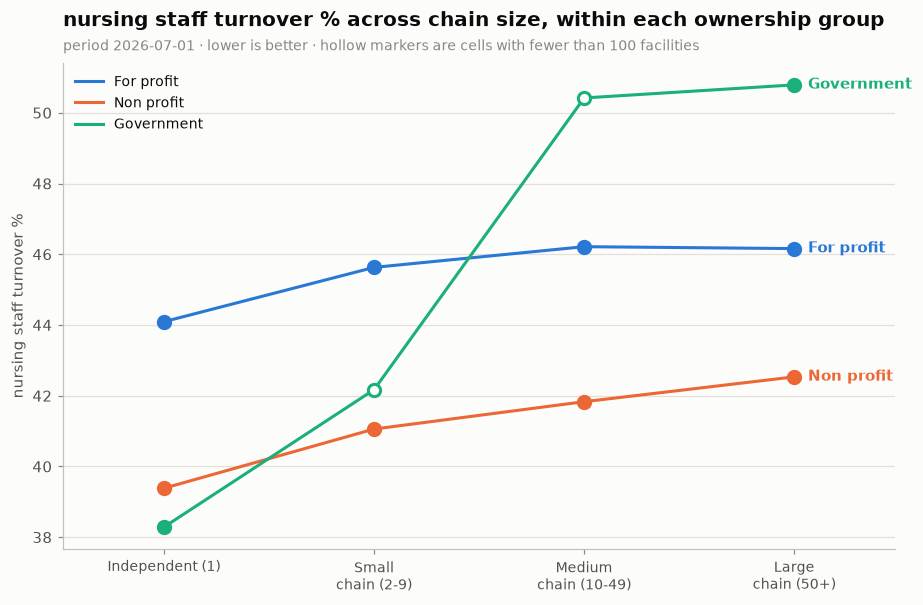

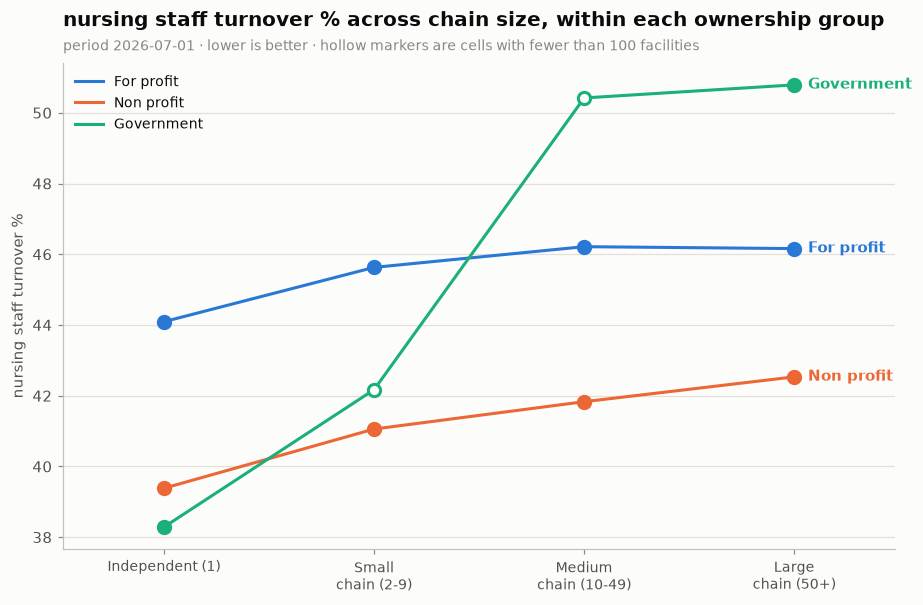

In [8]:
fig = charts.controlled_lines(cross, "turnover_pct", context)
fig.savefig("bq8_controlled_turnover.png", dpi=150, bbox_inches="tight")
fig

## 5. ตรวจว่าแนวโน้มนี้เป็นจริงในทุกกลุ่มหรือไม่ (เชิงตัวเลข)

สายตาบอกว่าลาด แต่ต้องนับให้ชัดว่า "ลดลงทุกขั้น" จริงหรือไม่ในแต่ละกลุ่ม

In [9]:
bands = list(cross["chain_size"].cat.categories)
for measure, direction in [("nurse_hprd", "ลดลง"), ("turnover_pct", "เพิ่มขึ้น"),
                           ("avg_rating", "ลดลง")]:
    print(f"\n{measure}  (คาดว่า{direction}ตามขนาดเครือ)")
    for owner, part in cross.groupby("ownership", observed=True):
        series = part.set_index("chain_size")[measure].reindex(bands).astype(float)
        diffs = series.diff().dropna()
        monotone = (diffs < 0).all() if direction == "ลดลง" else (diffs > 0).all()
        arrow = " → ".join(f"{v:.2f}" for v in series)
        print(f"   {str(owner):12} {arrow}   {'ทุกขั้น' if monotone else 'ไม่ทุกขั้น'}")


nurse_hprd  (คาดว่าลดลงตามขนาดเครือ)
   For profit   3.75 → 3.67 → 3.61 → 3.54   ทุกขั้น
   Non profit   4.38 → 4.13 → 4.03 → 3.47   ทุกขั้น
   Government   4.56 → 4.08 → 3.42 → 3.34   ทุกขั้น

turnover_pct  (คาดว่าเพิ่มขึ้นตามขนาดเครือ)
   For profit   44.09 → 45.63 → 46.21 → 46.16   ไม่ทุกขั้น
   Non profit   39.38 → 41.06 → 41.83 → 42.53   ทุกขั้น
   Government   38.29 → 42.17 → 50.42 → 50.79   ทุกขั้น

avg_rating  (คาดว่าลดลงตามขนาดเครือ)
   For profit   2.81 → 2.75 → 2.75 → 2.91   ไม่ทุกขั้น
   Non profit   3.66 → 3.56 → 3.47 → 3.18   ทุกขั้น
   Government   3.47 → 3.38 → 2.87 → 2.80   ทุกขั้น


## 6. ตรวจกับตัวเลขที่คำนวณด้วยมือ

`segment_cross` ถ่วงน้ำหนักชั่วโมงพยาบาลด้วยจำนวนผู้พักอาศัย เซลล์นี้คำนวณช่องหนึ่งขึ้นมาใหม่

In [10]:
raw = con.execute("""
    SELECT f.reported_total_nurse_hprd AS hprd, f.avg_residents_per_day AS residents
    FROM Fact_Facility_Monthly f
    JOIN Dim_Ownership o USING(ownership_key)
    JOIN Dim_Chain c USING(chain_key)
    WHERE f.snapshot_date_key = ? AND NOT f.is_suspect
      AND o.ownership_group = 'For profit' AND c.chain_size_band = 'Large chain (50+)'
""", [context["period_key"]]).df()

ok = raw.dropna(subset=["hprd"])
by_hand = (ok["hprd"] * ok["residents"]).sum() / ok["residents"].sum()
from_query = cross.loc[(cross["ownership"] == "For profit") &
                       (cross["chain_size"] == "Large chain (50+)"), "nurse_hprd"].iloc[0]
print(f"by hand        {by_hand:.6f}")
print(f"from queries   {float(from_query):.6f}")
print(f"match          {abs(by_hand - float(from_query)) < 1e-9}")
print(f"\nไม่ถ่วงน้ำหนัก {ok['hprd'].mean():.6f}  (ต่างกัน {ok['hprd'].mean() - by_hand:+.3f})")

by hand        3.540597
from queries   3.540597
match          True

ไม่ถ่วงน้ำหนัก 3.564046  (ต่างกัน +0.023)


## 7. คำตอบของ BQ8

_(สร้างจากตัวเลขจริง)_

In [11]:
ind = frame.loc[frame["segment"] == "Independent (1)"].iloc[0]
large = frame.loc[frame["segment"] == "Large chain (50+)"].iloc[0]

print(f"งวด {context['period']}\n")
print(f"{'':24}{'อิสระ':>12}{'เครือใหญ่':>14}{'ต่าง':>12}")
for label, col, fmt in [("คะแนนดาวเฉลี่ย", "avg_rating", "{:.2f}"),
                        ("ชม.พยาบาล/คน/วัน", "nurse_hprd", "{:.2f}"),
                        ("สัดส่วน RN", "rn_share", "{:.1%}"),
                        ("อัตราลาออก", "turnover_pct", "{:.1f}"),
                        ("ค่าปรับต่อเตียง", "fines_per_bed", "${:,.0f}"),
                        ("อัตราการเข้าพัก", "occupancy", "{:.1%}")]:
    a, b = float(ind[col]), float(large[col])
    print(f"{label:24}{fmt.format(a):>12}{fmt.format(b):>14}{fmt.format(b - a):>12}")

print(f"\nเครือใหญ่จัดพยาบาลน้อยกว่าบ้านอิสระ "
      f"{(1 - large['nurse_hprd'] / ind['nurse_hprd']) * 100:.1f}%")
print(f"แต่คะแนนดาวต่ำกว่า {ind['avg_rating'] - large['avg_rating']:.2f} ดาว")
print(f"และอัตราการเข้าพักสูงกว่า {(large['occupancy'] - ind['occupancy']) * 100:.1f} จุด")

งวด 2026-07-01

                               อิสระ     เครือใหญ่        ต่าง
คะแนนดาวเฉลี่ย                  3.24          2.92       -0.32
ชม.พยาบาล/คน/วัน                4.09          3.53       -0.57
สัดส่วน RN                     17.8%         16.4%       -1.4%
อัตราลาออก                      41.6          46.2         4.6
ค่าปรับต่อเตียง                 $270          $300         $30
อัตราการเข้าพัก                78.5%         80.1%        1.6%

เครือใหญ่จัดพยาบาลน้อยกว่าบ้านอิสระ 13.8%
แต่คะแนนดาวต่ำกว่า 0.32 ดาว
และอัตราการเข้าพักสูงกว่า 1.6 จุด


### คำตอบ: **ไม่ได้เปรียบด้านคุณภาพ — เป็นการกดต้นทุนแรงงาน**

หลักฐานสามชั้นที่ชี้ไปทางเดียวกัน

1. **ชั่วโมงพยาบาลลดลงตามขนาดเครืออย่างเป็นระบบ** และลดลง**ในทุกกลุ่มเจ้าของ**
   ไม่ใช่แค่ในกลุ่ม for-profit — จึงไม่ใช่ผลของรูปแบบการถือครองที่แฝงมา
2. **อัตราลาออกเพิ่มขึ้นตามขนาดเครือ** ซึ่งเป็นสิ่งที่คาดหวังได้เมื่อกดต้นทุนแรงงาน
3. **คะแนนดาวของเครือทุกขนาดต่ำกว่าบ้านอิสระ** ถ้าขนาดให้ข้อได้เปรียบด้านการบริหารจริง
   ควรเห็นผลตรงกันข้าม

**สิ่งที่เครือใหญ่ได้เปรียบจริงคือด้านพาณิชย์** — อัตราการเข้าพักสูงกว่าบ้านอิสระ
แปลว่าเก่งเรื่องหาผู้พักอาศัยมาเติมเตียง ไม่ใช่เรื่องดูแลผู้พักอาศัย

**ข้อยกเว้นที่ควรบันทึก:** ในกลุ่ม for-profit เครือ **ใหญ่สุด** คะแนนดีกว่าเครือ**กลาง**
เล็กน้อย และค่าปรับต่อเตียงต่ำกว่า — เป็นไปได้ว่าเครือที่ใหญ่ถึงระดับหนึ่งมีระบบกำกับ
การปฏิบัติตามกฎที่ชดเชยการจัดพยาบาลที่บางลงได้บางส่วน แนวโน้มจึงไม่ใช่เส้นตรง

### ข้อจำกัด

1. **หนึ่งงวดเท่านั้น** ข้อมูลเครือมีเฉพาะปี 2569 ยังตอบไม่ได้ว่าเครือทำให้บ้านแย่ลง
   หรือเครือไปซื้อบ้านที่แย่อยู่แล้ว — ต้องมีข้อมูลก่อน/หลังการเข้าซื้อ
2. **ช่องที่มีสถานพยาบาลน้อยไม่น่าเชื่อถือ** เครือของรัฐมีเพียง 91–173 แห่ง
   จุดกลวงในกราฟคือช่องเหล่านั้น
3. **`chain_size_band` มาจากคอลัมน์ที่ CMS รายงาน** ไม่ได้นับจากข้อมูลเอง
   ถ้า CMS นับผิด แถบก็ผิดตาม
4. ยังไม่ได้คุมตัวแปร**รัฐ** เครือใหญ่อาจกระจุกในรัฐที่ Medicaid จ่ายต่ำ